#### Wasserstein GAN
We have performed various experiments with training of WGANs. \
https://arxiv.org/pdf/1701.07875
Our experiments are listed as below: 
| Experiment # | Question # | Model Type          | Dataset Description                     | Key Parameters (e.g., Batch Size, Learning Rate) | Results (e.g., FID Score, Epochs) | Notes/Observations                              |
|--------------|------------|---------------------|------------------------------------------|-------------------------------------------------|----------------------------------|------------------------------------------------|
| 1            | Q7  Exp 1    | WGAN             |Animal Images, 90 classes | Batch Size: 128, Learning Rate: 5e-5         | FID: 227.82292   | RMSProp is used with weight clipping       |
| 2            | Q7   Exp 2    | WGAN with Gradient Penalty    |Animal Images, 90 classes | Batch Size: 128, Learning Rate:  1e-4         | FID: 227.51007    | Adam is used with gradient penalty parameter.  |


#### Question 7 Experiment 1: Wasserstein GAN 



In [5]:
# import libraries
import os
import torch
import torchvision
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader
from torchvision.utils import make_grid,save_image

import matplotlib.pyplot as plt
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')


In [6]:
path = os.path.join(os.getcwd(), 'data', 'augmented_animals')
mean = torch.tensor([0.50869316, 0.50057036, 0.44047505]) # Calculated for the given dataset
std = torch.tensor([0.20191325, 0.19737212, 0.20100889]) # Calculated for the given dataset

# Architecture parameters
image_size = 128
batch_size = 64
gen_feature = 128
latent_size = 100
dis_feature = 128
n_workers = 8
nc = 3
transform = transforms.Compose([
    transforms.Resize((image_size, image_size)),
    transforms.ToTensor(),
    transforms.Normalize(mean, std)
])
data = ImageFolder(path, transform=transform)
loader = DataLoader(data, batch_size=batch_size, shuffle=True, num_workers= n_workers)

In [7]:
class generator(nn.Module):
    def __init__(self, latent_size, image_size, generator_features):
        super(generator, self).__init__()
        self.latent_size = latent_size
        self.image_size = image_size
        self.generator_features = generator_features
        self.main = nn.Sequential(
            self.generator_block(latent_size, generator_features * 16, 4, 1, 0), # generator_features*8 x 4 x 4
            self.generator_block(generator_features * 16, generator_features * 8, 4, 2, 1), # generator_features*4 x 8 x 8
            self.generator_block(generator_features * 8, generator_features * 4, 4, 2, 1), # generator_features*2 x 16 x 16
            self.generator_block(generator_features * 4, generator_features * 2, 4, 2, 1),    # generator_features x 32 x 32
            self.generator_block(generator_features * 2, generator_features, 4, 2, 1),    # generator_features x 64 x 64
            nn.ConvTranspose2d(generator_features, 3, 4, 2, 1), # 3 x 128 x 128
            nn.Tanh()
        )
    def forward(self, x):
        return self.main(x)
    def generator_block(self, in_channels, out_channels, kernel_size, stride, padding):
        return nn.Sequential(
            nn.ConvTranspose2d(in_channels, out_channels, kernel_size, stride, padding),
            nn.BatchNorm2d(out_channels),
            nn.ReLU()
        )

class discriminator(nn.Module):
    def __init__(self, discriminator_features):
        super(discriminator, self).__init__()
        self.discriminator_features = discriminator_features
        self.main = nn.Sequential(
            self.discriminator_block(3, discriminator_features, 4, 2, 1), # discriminator_features x 64 x 64
            self.discriminator_block(discriminator_features, discriminator_features * 2, 4, 2, 1), # discriminator_features*2 x 32 x 32
            self.discriminator_block(discriminator_features * 2, discriminator_features * 4, 4, 2, 1), # discriminator_features*4 x 16 x 16
            self.discriminator_block(discriminator_features * 4, discriminator_features * 8, 4, 2, 1), # discriminator_features*8 x 8 x 8
            self.discriminator_block(discriminator_features * 8, discriminator_features * 16, 4, 2, 1), # discriminator_features*16 x 4 x 4
            nn.Conv2d(discriminator_features * 16, 1, 4, 1, 0), # 1 x 1 x 1
            # Sigmoid is not needed in WGAN
        )
    def forward(self, x):
        return self.main(x)
    def discriminator_block(self, in_channels, out_channels, kernel_size, stride, padding):
        return nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size, stride, padding),
            nn.BatchNorm2d(out_channels),
            nn.LeakyReLU(0.2)
        )
    
def weights_init(m):
    classname = m.__class__.__name__
    if classname.find('Conv') != -1:
        nn.init.normal_(m.weight.data, 0.0, 0.02)
    elif classname.find('BatchNorm') != -1:
        nn.init.normal_(m.weight.data, 1.0, 0.02)
        nn.init.constant_(m.bias.data, 0)

def test():
    N, in_channels, H, W = 64, 3, 128, 128
    x = torch.randn((N, in_channels, H, W)).to(device)  # 64,3,128,128
    D = discriminator(dis_feature).to(device)
    assert D(x).shape == (N, 1, 1, 1), "Critic test failed"

    G = generator(latent_size, image_size, gen_feature).to(device)
    z = torch.randn((N, latent_size, 1, 1)).to(device)
    assert G(z).shape == (N, in_channels, H, W), "Generator test failed"
    print("All architectural tests passed")
test()

All architectural tests passed


In [ ]:
# Training parameters
num_epochs = 60
lr = 5e-5
beta1 = 0.5
beta2 = 0.999
n_critic = 5
weight_clip = 0.01

G = generator(latent_size, image_size, gen_feature).to(device)
D = discriminator(dis_feature).to(device)

G.apply(weights_init)
D.apply(weights_init)

D_optim = optim.Adam(D.parameters(), lr=lr, betas=(beta1, beta2))
G_optim = optim.Adam(G.parameters(), lr=lr, betas=(beta1, beta2))

D_loss = []
G_loss = []

fixed_noise = torch.randn(batch_size, latent_size, 1, 1).to(device)

os.makedirs('wgan_output', exist_ok=True)

for i in range(num_epochs):
    for j, (real, _) in enumerate(loader):

        for _ in range(n_critic):
            real = real.to(device)
            real = real.requires_grad_(True)

            noise = torch.randn(batch_size, latent_size, 1, 1).to(device)
            fake = G(noise)
            fake = fake.requires_grad_(True)

            D_real = D(real).view(-1)
            D_fake = D(fake).view(-1)
            loss_D = - (D_real.mean() - D_fake.mean())


            D.zero_grad()
            loss_D.backward()
            D_optim.step()
            for p in D.parameters():
                p.data.clamp_(-weight_clip, weight_clip)  # Clipped weights


        noise = torch.randn(batch_size, latent_size, 1, 1).to(device)
        fake = G(noise)
        fake = fake.requires_grad_(True)
        D_fake = D(fake).view(-1)
        loss_G = - D_fake.mean()

        G.zero_grad()
        loss_G.backward()
        G_optim.step()

        if j % 100 == 0:
            print(f'Epoch {i}/{num_epochs}, Step {j}/{len(loader)}, Loss D: {loss_D.item():.5f}, Loss G: {loss_G.item():.5f}')
            D_loss.append(loss_D.item())
            G_loss.append(loss_G.item())
            with torch.no_grad():
                    fake_images = G(fixed_noise).detach().cpu()
                    save_image(make_grid(fake_images, padding=2, normalize=True), f'wgan_output/{i}_{j}.png', normalize=True)

torch.save(G, 'wgan_generator.pth')

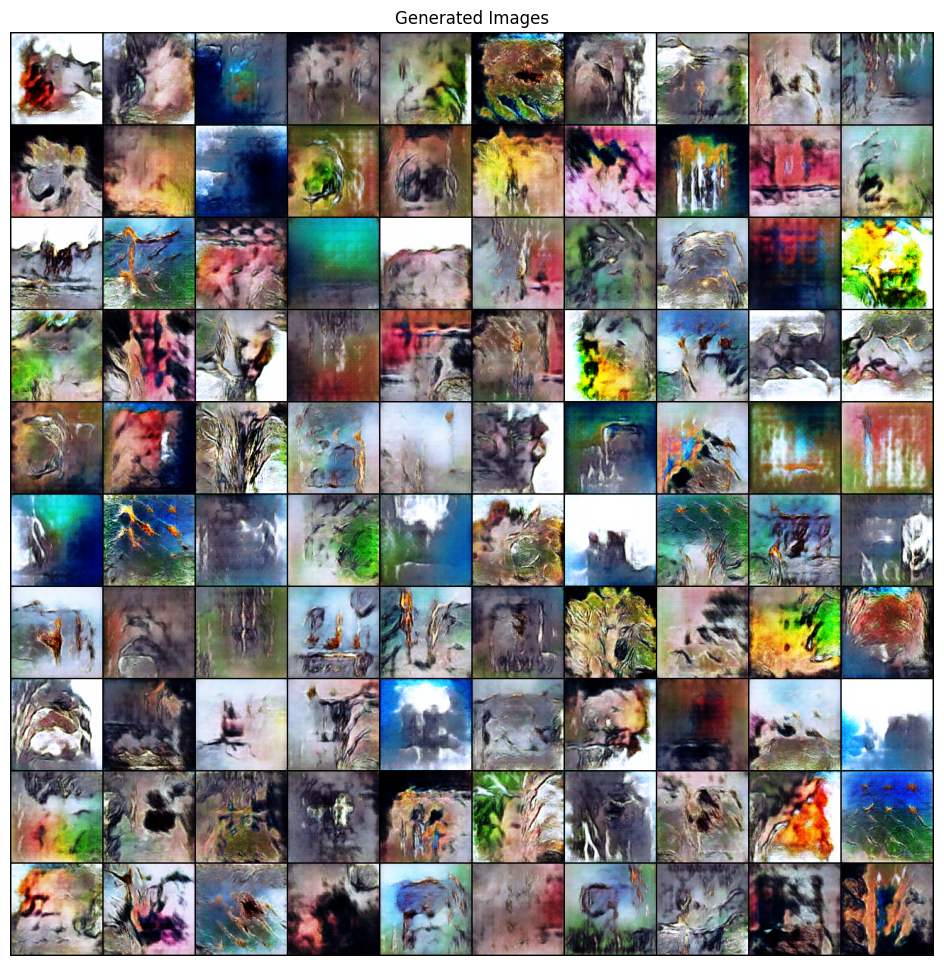

(1000, 3, 128, 128)
(1000, 3, 128, 128)


In [14]:
# plt.plot(D_loss, label='Discriminator Loss')
# plt.plot(G_loss, label='Generator Loss')
# plt.legend()
# plt.show()

# Generate images
G = torch.load('wgan_generator.pth',weights_only=False)
fixed_noise = torch.randn(100, latent_size, 1, 1).to(device)
generated = G(fixed_noise)
plt.figure(figsize=(12,12))
plt.axis("off")
plt.title("Generated Images")
plt.imshow(make_grid(generated.detach().cpu(), nrow=10, padding=2, normalize=True).permute(1, 2, 0))
plt.show()
import numpy as np
fake_images = []
for i in range(1000):
    noise = torch.randn(1, latent_size, 1, 1).to(device)
    img = G(noise).detach().cpu().numpy().squeeze()
    fake_images.append(img)
fake_images = np.array(fake_images)
# 1000 real fake_images in tensor format
real_images = []
for i in range(1000):
    img, _ = data[i]
    real_images.append(img.numpy())
real_images = np.array(real_images)


FID Calculation

In [8]:
import numpy as np
fake_images = []
G = torch.load('wgan_generator.pth',weights_only=False)
for i in range(1000):
    noise = torch.randn(1, latent_size, 1, 1).to(device)
    img = G(noise).detach().cpu().numpy().squeeze()
    # 0 to 1 normalization
    img = (img - img.min()) / (img.max() - img.min())
    fake_images.append(img)
fake_images = np.array(fake_images)
# 1000 real fake_images in tensor format
real_images = []
for i in range(1000):
    img, _ = data[i]
    # 0 to 1 normalization
    img = (img.numpy() - img.numpy().min()) / (img.numpy().max() - img.numpy().min())
    real_images.append(img)
real_images = np.array(real_images)

import torch
from torcheval.metrics import FrechetInceptionDistance

# Assuming you have real and fake images as tensors
# real_images: Tensor of shape (1000, 3, 128, 128)
# fake_images: Tensor of shape (1000, 3, 128, 128)

# Initialize FID metric calculator
fid_metric = FrechetInceptionDistance(feature_dim=2048)  # FID is typically computed using Inception-V3 features with 2048 dimensions
# normalize the images

# Update the FID metric with real and fake images
fid_metric.update(torch.tensor(real_images), is_real=True)
fid_metric.update(torch.tensor(fake_images), is_real=False)

# Compute the FID score
fid_score = fid_metric.compute()

print(f"FID Score: {fid_score.item()}")

FID Score: 227.8229217529297


## Comparision of Vanilla GAN and WGAN


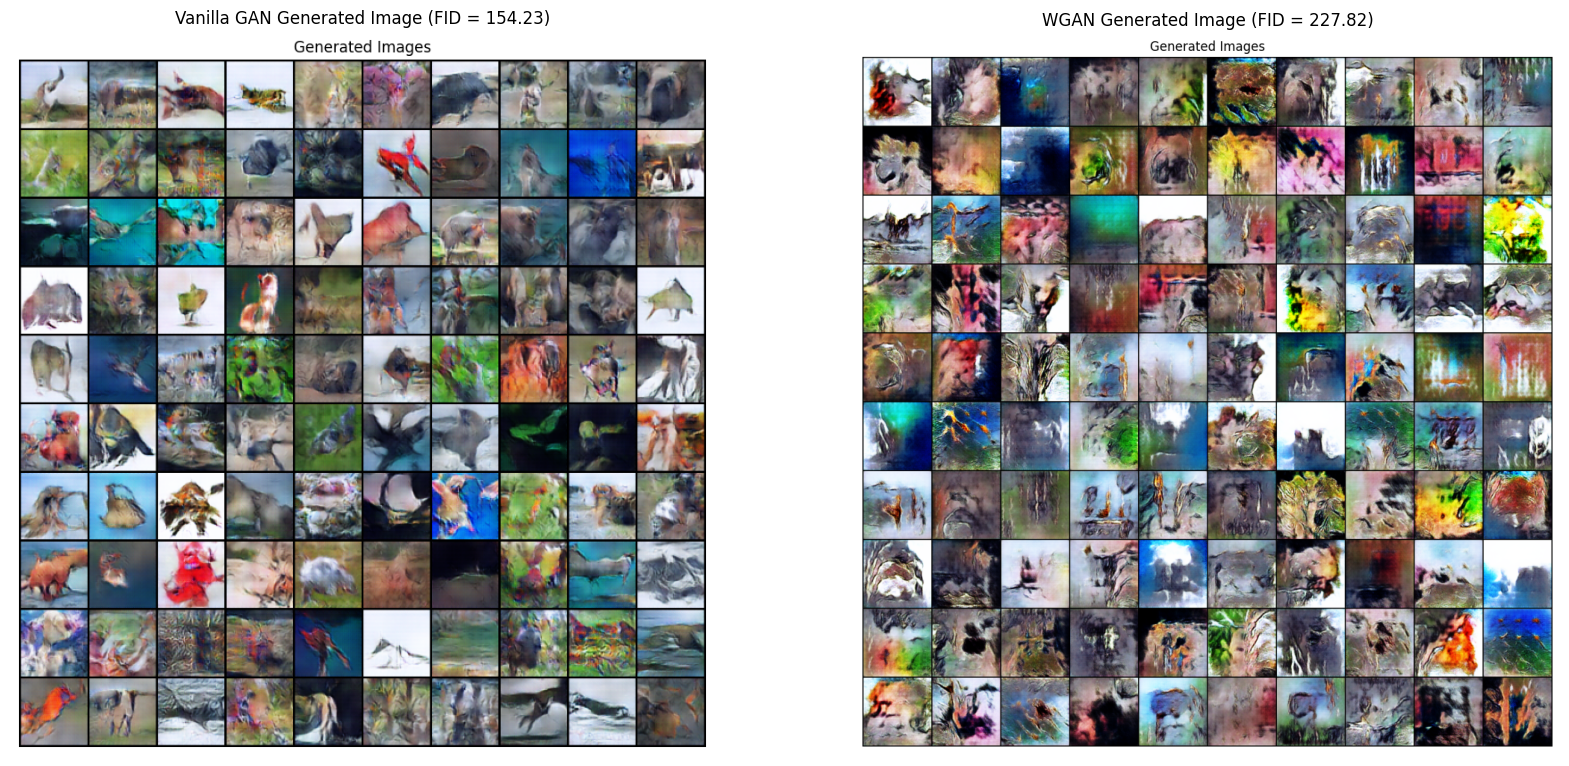

In [8]:
import matplotlib.pyplot as plt
from PIL import Image

# Define the paths to the two images
image_path1 = 'gen_images.png'
image_path2 = 'wgan_output.png'

# Load the images
image1 = Image.open(image_path1)
image2 = Image.open(image_path2)

# Plot the images
plt.figure(figsize=(20,10))

# Display the first image
plt.subplot(1, 2, 1)
plt.imshow(image1)
plt.title('Vanilla GAN Generated Image (FID = 154.23)')
plt.axis('off')

# Display the second image
plt.subplot(1, 2, 2)
plt.imshow(image2)
plt.title('WGAN Generated Image (FID = 227.82)')
plt.axis('off')

# Show the plot
plt.show()

Both experiments are done at same number of epochs for comparision: \
#### Observation: 
1) Vanilla GAN gave us more clearer images!
2) FID of Vanilla GAN is lesser but it is possible that at higher epoches WGAN do better job.